# **Assignment 15: Clustering Analysis (K-Means & DBSCAN on EastWestAirlines.xlsx)**

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

**1. Data Preprocessing & Exploratory Data Analysis (EDA)**

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB
None

--- Summary Statistics ---
               ID#       Balance    Qual_miles    cc1_miles    cc2_miles  \
count  3999.000000  3.999000e+03   3999.000000  3999.000000  3999.00000

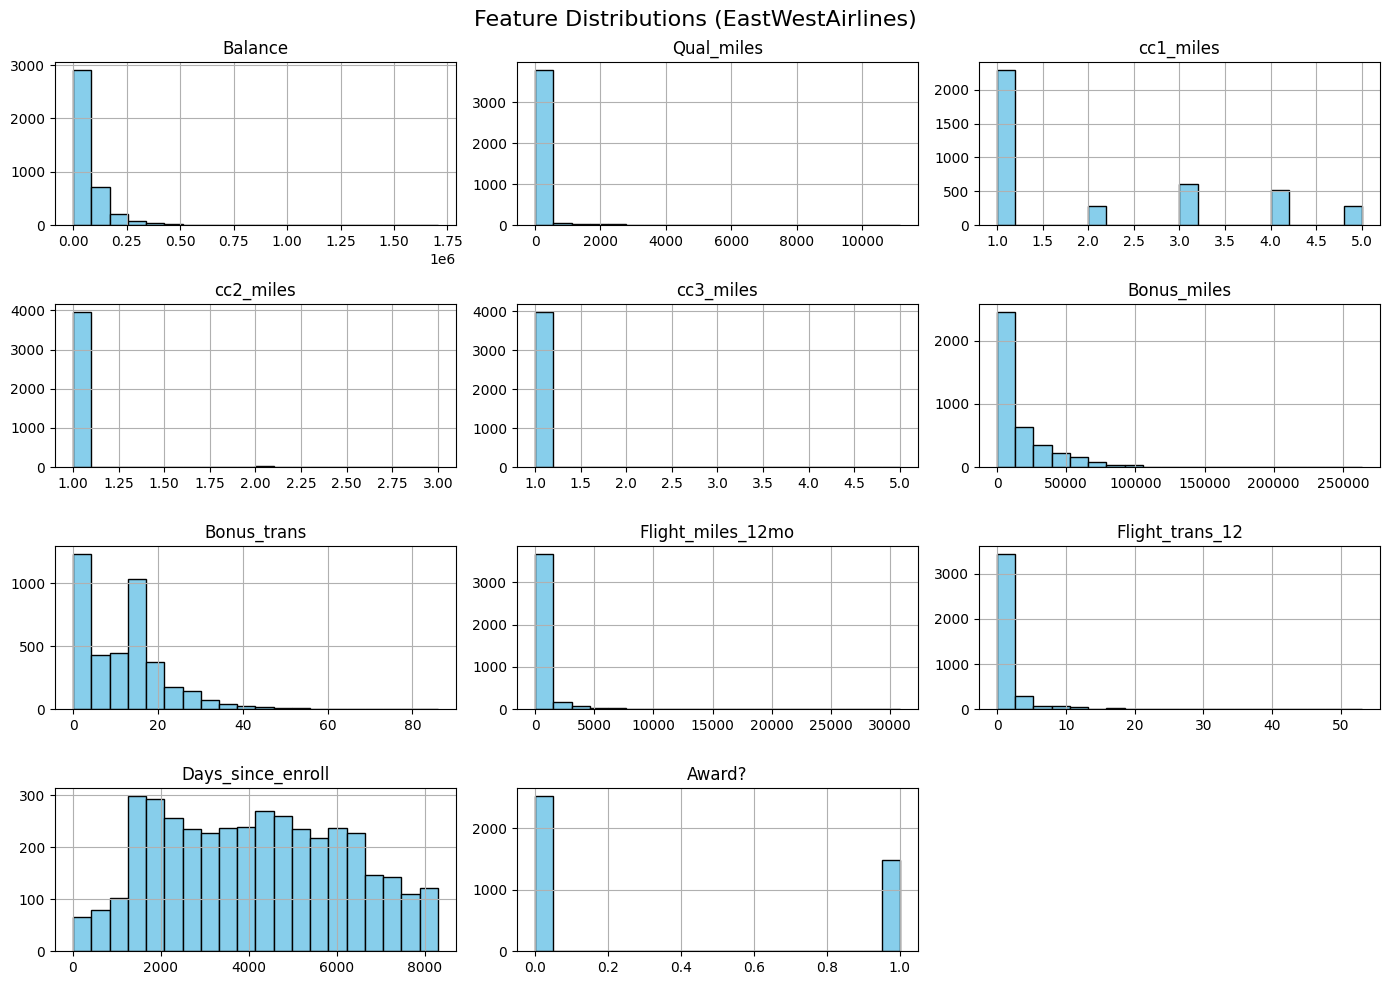

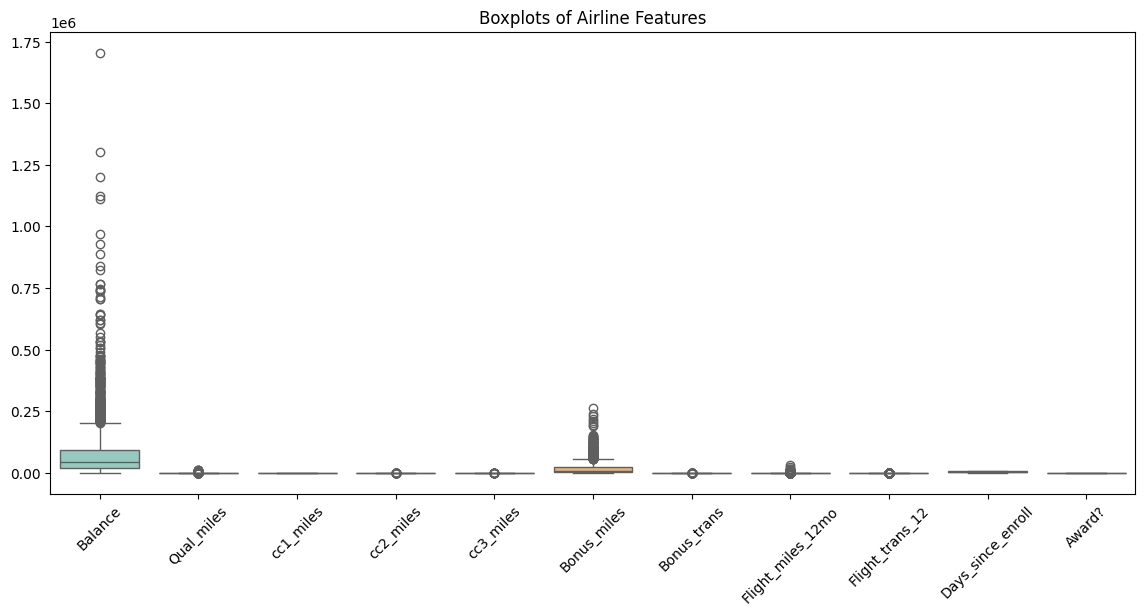

In [5]:
# Load dataset (Sheet 2: 'data')
df_air = pd.read_excel("/content/EastWestAirlines.xlsx", sheet_name="data")

print("--- Dataset Information ---")
print(df_air.info())

print("\n--- Summary Statistics ---")
print(df_air.describe())

# Check missing values
print("\n--- Missing Values Count ---")
print(df_air.isnull().sum())
X_features = df_air.drop(columns=["ID#"])
X_features.hist(
    figsize=(14, 10), bins=20, color="skyblue", edgecolor="black"
)
plt.suptitle("Feature Distributions (EastWestAirlines)", fontsize=16)
plt.tight_layout()
plt.show()
plt.figure(figsize=(14, 6))
sns.boxplot(data=X_features, palette="Set3")
plt.title("Boxplots of Airline Features")
plt.xticks(rotation=45)
plt.show()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

**2. K-Means Clustering & Parameter Tuning**

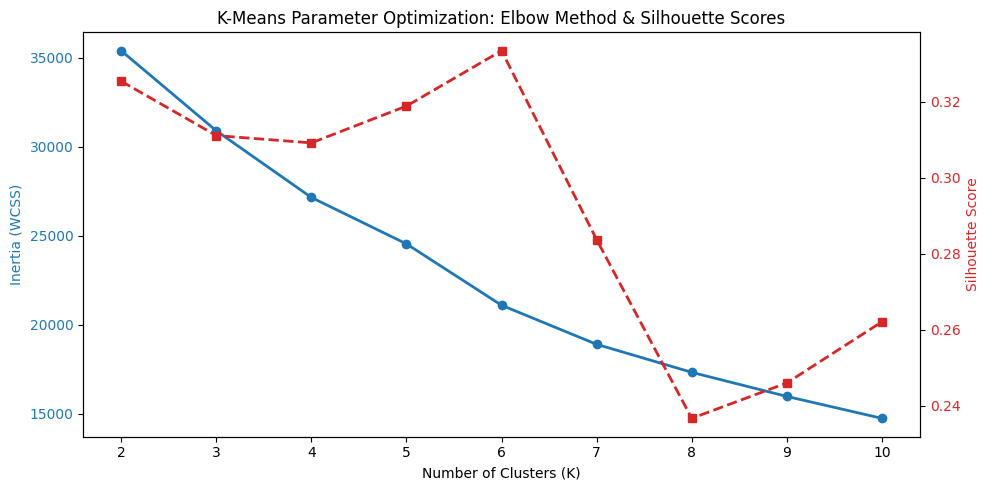


--- K-Means (K=6) Silhouette Score: 0.3334 ---


In [6]:
inertias = []
silhouette_scores_km = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores_km.append(silhouette_score(X_scaled, labels))
fig, ax1 = plt.subplots(figsize=(10, 5))

color = "tab:blue"
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia (WCSS)", color=color)
ax1.plot(k_range, inertias, marker="o", color=color, linewidth=2)
ax1.tick_params(axis="y", labelcolor=color)

ax2 = ax1.twinx()
color = "tab:red"
ax2.set_ylabel("Silhouette Score", color=color)
ax2.plot(
    k_range,
    silhouette_scores_km,
    marker="s",
    linestyle="--",
    color=color,
    linewidth=2,
)
ax2.tick_params(axis="y", labelcolor=color)

plt.title("K-Means Parameter Optimization: Elbow Method & Silhouette Scores")
fig.tight_layout()
plt.show()
optimal_k = 6
kmeans_opt = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_air["KMeans_Cluster"] = kmeans_opt.fit_predict(X_scaled)

km_sil = silhouette_score(X_scaled, df_air["KMeans_Cluster"])
print(
    f"\n--- K-Means (K={optimal_k}) Silhouette Score: {km_sil:.4f} ---"
)

**3. DBSCAN Clustering Implementation**

In [7]:
# Parameter Tuning for DBSCAN (eps=1.5, min_samples=5)
dbscan = DBSCAN(eps=1.5, min_samples=5)
df_air["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)

# Calculate Silhouette Score for non-noise points (-1 denotes noise)
non_noise_mask = df_air["DBSCAN_Cluster"] != -1
db_sil = silhouette_score(
    X_scaled[non_noise_mask], df_air["DBSCAN_Cluster"][non_noise_mask]
)

print(
    f"\n--- DBSCAN Silhouette Score (excluding noise): {db_sil:.4f} ---"
)
print("DBSCAN Cluster Counts (including -1 for Noise):")
print(df_air["DBSCAN_Cluster"].value_counts())


--- DBSCAN Silhouette Score (excluding noise): 0.2940 ---
DBSCAN Cluster Counts (including -1 for Noise):
DBSCAN_Cluster
 0    2411
 1    1250
-1     310
 2      15
 3       8
 4       5
Name: count, dtype: int64


**4. Cluster Visualization & Interpretation**

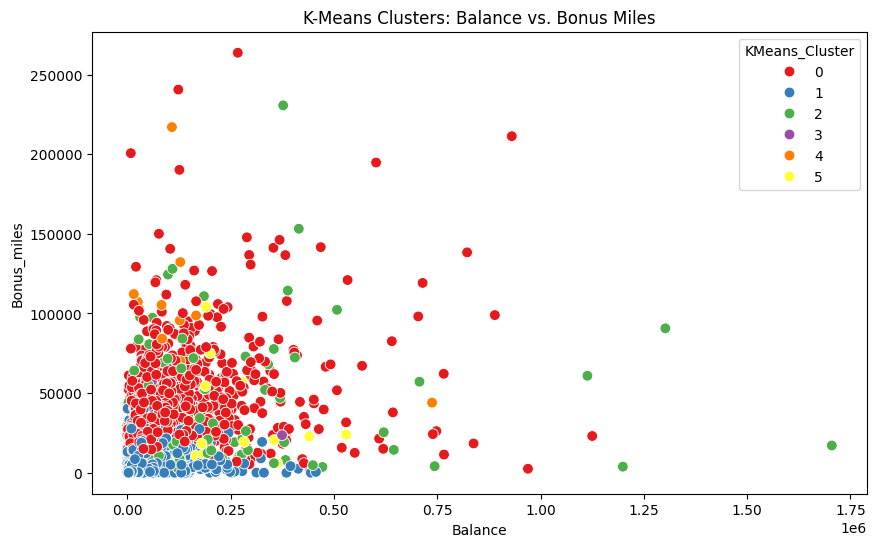

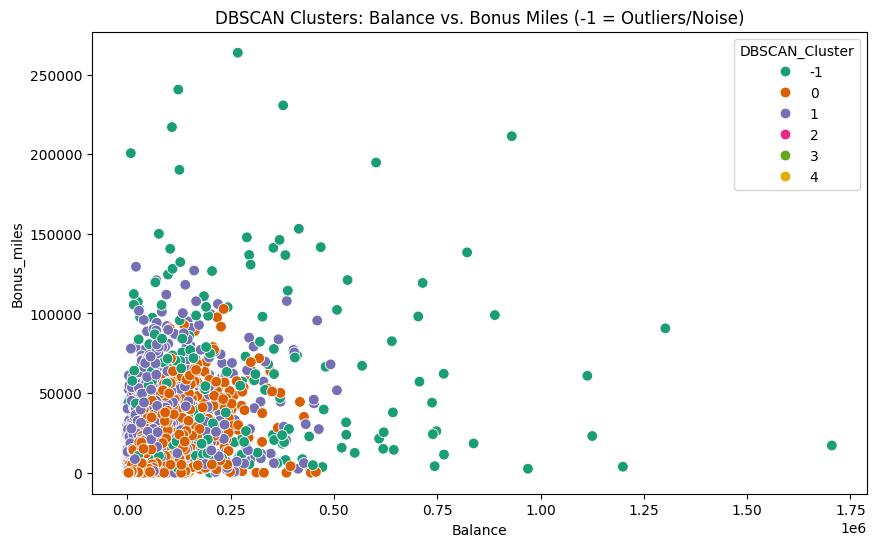


--- K-Means Cluster Characteristics (Mean Values) ---
                      Balance   Bonus_miles  Flight_miles_12mo  \
KMeans_Cluster                                                   
0               117306.664804  39273.747007         347.403033   
1                43521.857488   4610.947665         198.170692   
2               188155.664336  32995.580420        5739.692308   
3                68876.581395  14689.837209         582.627907   
4               138061.400000  93927.866667         506.666667   
5               119660.491803  18683.475410         963.639344   

                Days_since_enroll  
KMeans_Cluster                     
0                     4896.240223  
1                     3697.207729  
2                     4679.251748  
3                     3968.930233  
4                     4613.866667  
5                     3971.491803  


In [8]:
# Scatter plots: Balance vs Bonus Miles across K-Means Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="Balance",
    y="Bonus_miles",
    hue="KMeans_Cluster",
    data=df_air,
    palette="Set1",
    s=60,
)
plt.title("K-Means Clusters: Balance vs. Bonus Miles")
plt.show()

# Scatter plots: Balance vs Bonus Miles across DBSCAN Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="Balance",
    y="Bonus_miles",
    hue="DBSCAN_Cluster",
    data=df_air,
    palette="Dark2",
    s=60,
)
plt.title("DBSCAN Clusters: Balance vs. Bonus Miles (-1 = Outliers/Noise)")
plt.show()

# Cluster Profiles Summary Insights
print("\n--- K-Means Cluster Characteristics (Mean Values) ---")
print(
    df_air.groupby("KMeans_Cluster")[
        ["Balance", "Bonus_miles", "Flight_miles_12mo", "Days_since_enroll"]
    ].mean()
)